In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from functools import reduce
import ast
import re
import numpy as np
import pyvista as pv
import json
from pathlib import Path
from config import METRICS_DIR, PATIENT_MESHES_DIR, IMAGES_DIR
from process_metrics_per_experiment import build_dataframe_from_versions_metrics, groupby_and_agg



PROJ_ROOT path is: /home/navarri/AtriaProject/deepcsdf-atria




In [ ]:
experiment_name="LipAlphaCodeRegAndLatentSize"
add_column_name_1="alpha"
add_column_name_2="code_reg"
add_column_name_3="latent_size"
get_specs_flatkey1="lipschitz_alpha"
get_specs_flatkey2="code_reg_lambda"
get_specs_flatkey3="Network_specs.latent_size"

In [ ]:
df_train_all, df_test_all = build_dataframe_from_versions_metrics(
    metrics_directory=METRICS_DIR,
    experiment_name=experiment_name,
    add_column_names=[add_column_name_1, add_column_name_2, add_column_name_3],
    get_specs_flatkeys=[get_specs_flatkey1, get_specs_flatkey2, get_specs_flatkey3]
)

In [ ]:
df_train_all["code_reg"] = df_train_all["code_reg"].apply( lambda x: float(x))
df_test_all["code_reg"] = df_test_all["code_reg"].apply( lambda x: float(x))

df_train_all["alpha"] = df_train_all["alpha"].apply( lambda x: float(x))
df_test_all["alpha"] = df_test_all["alpha"].apply( lambda x: float(x))

In [ ]:
df_train = df_train_all.query(" latent_size == '64' ")
df_test = df_test_all.query(" latent_size == '64' ")

Check:

In [ ]:
print( sorted( df_train["version"].unique()) )
print( sorted( df_test["version"].unique()) )
print(  df_train["metric"].unique() ) 
print(  df_test["metric"].unique() ) 
print(  df_train[add_column_name_1].unique() ) 
print(  df_test[add_column_name_1].unique() ) 
print(  df_train[add_column_name_2].unique() ) 
print(  df_test[add_column_name_2].unique() ) 
print(  df_train[add_column_name_3].unique() ) 
print(  df_test[add_column_name_3].unique() ) 

[1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46, 49, 52, 55, 58, 61, 64, 67, 70, 73]
[1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46, 49, 52, 55, 58, 61, 64, 67, 70, 73]
['LDDMM' 'chamfer' 'haussdorff']
['chamfer' 'LDDMM' 'haussdorff']
[1.e-03 1.e-05 1.e-06 1.e-07 1.e-04]
[1.e-04 1.e-07 1.e-05 1.e-03 1.e-06]
[1.e-03 1.e-06 1.e-05 1.e-04 1.e-07]
[1.e-06 1.e-07 1.e-04 1.e-05 1.e-03]
['64']
['64']


In [ ]:
df_all_train_chd = df_train.query(" metric == 'chamfer' ").drop(columns="metric")
df_all_train_hsd = df_train.query(" metric == 'haussdorff' ").drop(columns="metric")
df_all_train_lddmm = df_train.query(" metric == 'LDDMM' ").drop(columns="metric")

df_all_test_chd = df_test.query(" metric == 'chamfer' ").drop(columns="metric")
df_all_test_hsd = df_test.query(" metric == 'haussdorff' ").drop(columns="metric")
df_all_test_lddmm = df_test.query(" metric == 'LDDMM' ").drop(columns="metric")

In [ ]:
groupby_columns = [add_column_name_1, add_column_name_2]

# TRAIN shapes
df_train_chd = groupby_and_agg(df_all_train_chd, groupby_columns, grouby_value="value")
df_train_hsd = groupby_and_agg(df_all_train_hsd, groupby_columns, grouby_value="value")
df_train_lddmm = groupby_and_agg(df_all_train_lddmm, groupby_columns, grouby_value="value")

# TEST shapes
df_test_chd = groupby_and_agg(df_all_test_chd, groupby_columns, grouby_value="value")
df_test_hsd = groupby_and_agg(df_all_test_hsd, groupby_columns, grouby_value="value")
df_test_lddmm = groupby_and_agg(df_all_test_lddmm, groupby_columns, grouby_value="value")

assign_train_dataset = {
    "Chamfer" : df_train_chd,
    "Haussdorff" : df_train_hsd,
    "LDDMM" : df_train_lddmm
}

assign_test_dataset = {
    "Chamfer" : df_test_chd,
    "Haussdorff" : df_test_hsd,
    "LDDMM" : df_test_lddmm
}

## PLOTs: train and test side by side with same scale in y axis

In [ ]:
def plot_(
    save_fname,
    df_train,
    df_test,
    legend_column,
    x_axis_column,
    legend_tags,
    x_label,
    reorder_categrorical_x_axis = False,
    suptitle="",
    suptitle_fontsize=16,
    fontsize=16,
    legend_title="",
    legend_title_fontsize=11,
    legend_items_fontsize=11,
    format_legend_items_tags_scientific_notation=False,
    set_xscale_log=False,
    set_yscale_log=False,
    axis_ticklabelsize=11,
    x_label_fontsize=16,
    plots_linewidth=2.5,
    scatter_size=80
    ):
    
    # Convert x-axis to numeric if possible
    df_train[x_axis_column] = pd.to_numeric(df_train[x_axis_column], errors='ignore')
    df_test[x_axis_column]  = pd.to_numeric(df_test[x_axis_column], errors='ignore')

    # Then sort if needed
    if reorder_categrorical_x_axis:
        df_train = df_train.sort_values(x_axis_column)
        df_test  = df_test.sort_values(x_axis_column)

    # Colors for actual plots
    cmap_tr = plt.get_cmap("Reds")
    colors_tr = [cmap_tr(i / len(legend_tags) * 0.7 + 0.3 ) for i in range(len(legend_tags))]
    cmap_te = plt.get_cmap("Blues")
    colors_te = [cmap_te(i / len(legend_tags) * 0.7 + 0.3 ) for i in range(len(legend_tags))]

    # Grayscale for batch size legend
    cmap_gray = plt.get_cmap("Greys")
    gray_colors = [cmap_gray(i / len(legend_tags) * 0.7 + 0.3) for i in range(len(legend_tags))]

    fontsize = 14
    fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True)  # side by side, shared y axis


    # ------------------------------
    # Plot Train
    # ------------------------------
    ax = axs[0]
    for i, tag in enumerate(legend_tags):
        subset = (
            df_train[df_train[legend_column] == tag]
            .sort_values(x_axis_column)
        )
        ax.plot(subset[x_axis_column], subset['mean'], c=colors_tr[i], linewidth=plots_linewidth, alpha=0.9)
        ax.scatter(subset[x_axis_column], subset['mean'], color=colors_tr[i], s=scatter_size)
    
    if set_xscale_log:
        ax.set_xscale('log')
    if set_yscale_log:
        ax.set_yscale('log')

    ax.set_xlabel(x_label, fontsize=x_label_fontsize, labelpad=15)
    ax.set_ylabel("Value", fontsize=fontsize, labelpad=15)
    ax.grid(True, which='major', linestyle='-', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=axis_ticklabelsize)

    # ------------------------------
    # Plot Test
    # ------------------------------
    ax = axs[1]
    for i, tag in enumerate(legend_tags):
        subset = (
            df_test[df_test[legend_column] == tag]
            .sort_values(x_axis_column)
        )
        ax.plot(subset[x_axis_column], subset['mean'], c=colors_te[i], linewidth=plots_linewidth, alpha=0.9)
        ax.scatter(subset[x_axis_column], subset['mean'], color=colors_te[i], s=scatter_size)
    
    if set_xscale_log:
        ax.set_xscale('log')
        
    ax.set_xlabel(x_label, fontsize=x_label_fontsize, labelpad=15) 
    ax.grid(True, which='major', linestyle='-', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=axis_ticklabelsize)

    plt.suptitle(suptitle, fontsize=suptitle_fontsize)


    # ------------------------------
    # Shared legend (grayscale)
    # ------------------------------
    if format_legend_items_tags_scientific_notation:
        legend_handles = [
            Line2D([0], [0], color=gray_colors[i], linewidth=3, label=f"{float(tag):.0e}") #f"{tag:.0e}") this has to be changed manually ...
            for i, tag in enumerate(legend_tags)
        ]
    else:
        legend_handles = [
            Line2D([0], [0], color=gray_colors[i], linewidth=3, label=tag) 
            for i, tag in enumerate(legend_tags)
        ]

    which_shapes_handles = [ 
        Line2D([0], [0], color=colors_tr[-1], linewidth=3, label="train"),
        Line2D([0], [0], color=colors_te[-1], linewidth=3, label="test")
    ]
                            

    # Shrink subplots to make room on the right
    fig.subplots_adjust(right=0.78, wspace=0.1)  # the subplots will fit in left 78% of figure width

    # Place legend to the right of plots
    fig.legend(
        handles=legend_handles,
        loc='center left',
        bbox_to_anchor=(0.8, 0.5),  # x, y in figure fraction coordinates
        fontsize=legend_items_fontsize,
        title=legend_title, #r"$\alpha$",
        title_fontsize=legend_title_fontsize,
        borderaxespad=0
    )

    # Second legend: train/test (colors)
    fig.legend(
        handles=which_shapes_handles,
        loc='center left',
        bbox_to_anchor=(0.8, 0.2),
        fontsize=16,
        # title="Dataset",
        # title_fontsize=16,
        borderaxespad=0
    )

    plt.savefig(save_fname, dpi=300, transparent=True)
    plt.show()
    plt.close(fig)

In [ ]:
save_dir = IMAGES_DIR / experiment_name
save_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# ------------------------------
# setup things for legend and x axis labels
# ------------------------------
legend_column, x_axis_column = add_column_name_2, add_column_name_1
# legend_tags = sorted( df_train[legend_column].unique(), key= lambda x: len(x) )
legend_tags = sorted(df_train[legend_column].unique())

#label of x axis
x_label = r"$\lambda_{lip}$"

legend_title = r"$\lambda_{prior}$"

print(legend_column)
print(x_axis_column)

code_reg
alpha


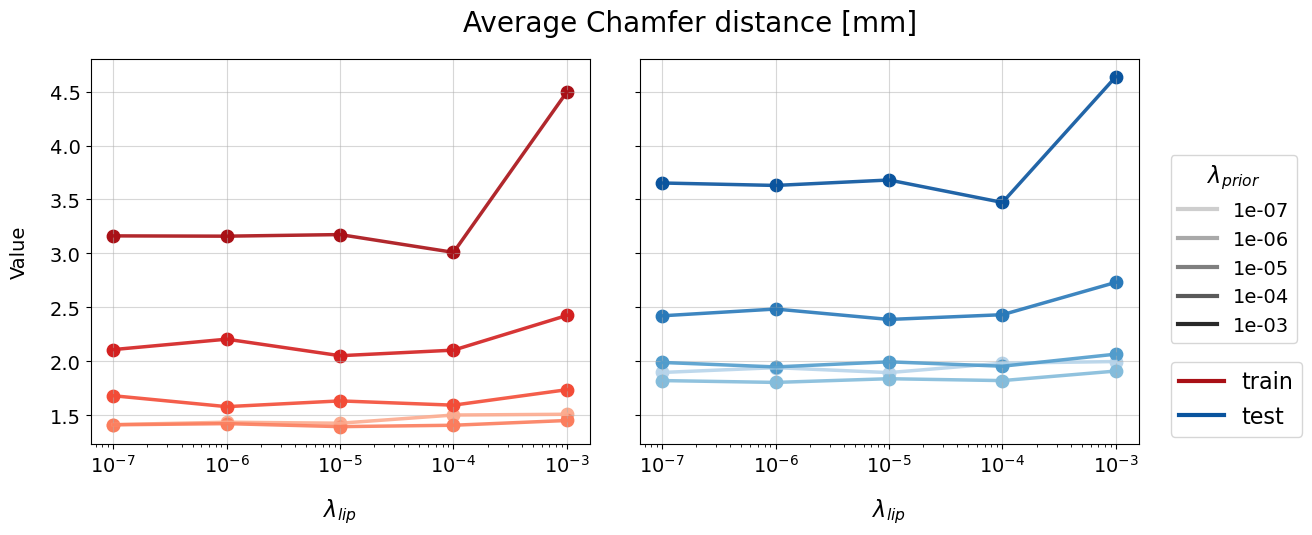

In [ ]:
metric = "Chamfer"

save_fname = save_dir / f"{experiment_name}-avg{metric}-trainVStest.svg"

df_train = assign_train_dataset[metric]
df_test = assign_test_dataset[metric]

plot_(save_fname, df_train, df_test, legend_column, x_axis_column, legend_tags, x_label,
      reorder_categrorical_x_axis=False,
      suptitle=f"Average {metric} distance [mm]",
      suptitle_fontsize=20,
      legend_title=legend_title,
      legend_title_fontsize=16,
      legend_items_fontsize=14,
      format_legend_items_tags_scientific_notation=True,
      axis_ticklabelsize=14,
      x_label_fontsize=16,
      set_xscale_log=True,
      )

code_reg
alpha


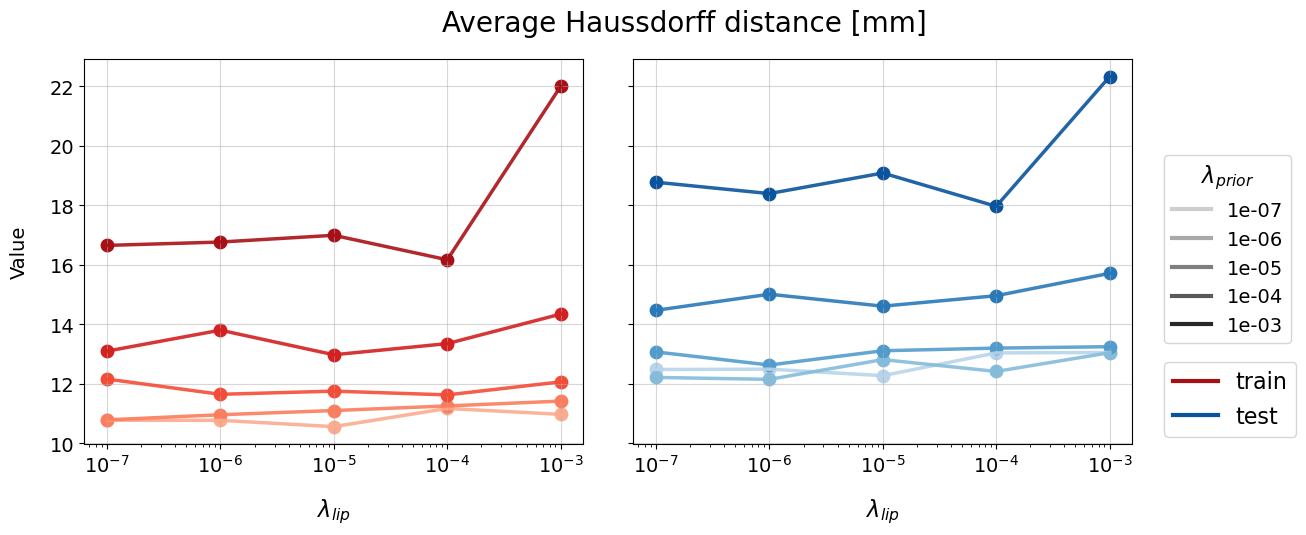

In [ ]:
metric = "Haussdorff"

save_fname = save_dir / f"{experiment_name}-avg{metric}-trainVStest.svg"

df_train = assign_train_dataset[metric]
df_test = assign_test_dataset[metric]

# ------------------------------
# setup things for legend and x axis labels
# ------------------------------
legend_column, x_axis_column = add_column_name_2, add_column_name_1

print(legend_column)
print(x_axis_column)
# legend_tags = sorted( df_train[legend_column].unique(), key= lambda x: len(x) )
legend_tags = sorted(df_train[legend_column].unique())

#label of x axis
x_label = r"$\lambda_{lip}$"

legend_title = r"$\lambda_{prior}$"

plot_(save_fname, df_train, df_test, legend_column, x_axis_column, legend_tags, x_label,
      reorder_categrorical_x_axis=False,
      suptitle=f"Average {metric} distance [mm]",
      suptitle_fontsize=20,
      legend_title=legend_title,
      legend_title_fontsize=16,
      legend_items_fontsize=14,
      format_legend_items_tags_scientific_notation=True,
      axis_ticklabelsize=14,
      x_label_fontsize=16,
      set_xscale_log=True,
      )

code_reg
alpha


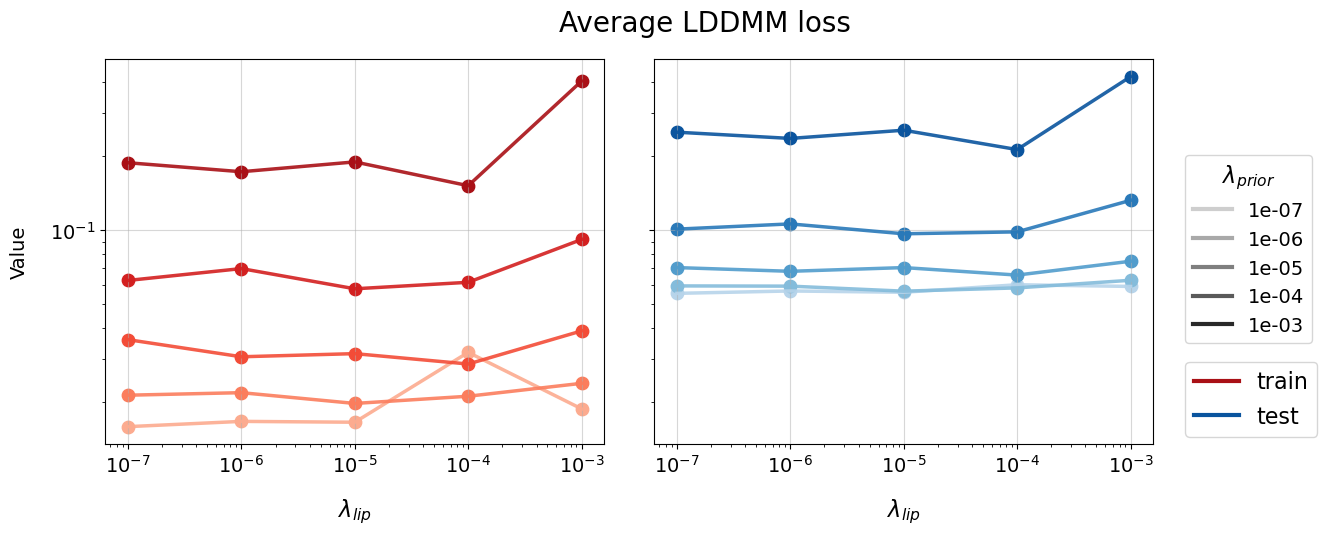

In [ ]:
metric = "LDDMM"

save_fname = save_dir / f"{experiment_name}-avg{metric}-trainVStest.svg"

df_train = assign_train_dataset[metric]
df_test = assign_test_dataset[metric]

# ------------------------------
# setup things for legend and x axis labels
# ------------------------------
legend_column, x_axis_column = add_column_name_2, add_column_name_1

print(legend_column)
print(x_axis_column)
# legend_tags = sorted( df_train[legend_column].unique(), key= lambda x: len(x) )
legend_tags = sorted(df_train[legend_column].unique())

#label of x axis
x_label = r"$\lambda_{lip}$"

legend_title = r"$\lambda_{prior}$"

plot_(save_fname, df_train, df_test, legend_column, x_axis_column, legend_tags, x_label,
      reorder_categrorical_x_axis=False,
      suptitle=f"Average {metric} loss",
      suptitle_fontsize=20,
      legend_title=legend_title,
      legend_title_fontsize=16,
      legend_items_fontsize=14,
      format_legend_items_tags_scientific_notation=True,
      axis_ticklabelsize=14,
      x_label_fontsize=16,
      set_xscale_log=True,
      set_yscale_log=True
      )